# Model Interpretation

The objective of this notebook is to interpret the selected machine learning model and identify the behavioural features that contribute most significantly to early player retention prediction.

Model interpretation improves transparency by explaining how behavioural features influence model predictions. Both global feature importance and local prediction explanations are presented using Logistic Regression coefficients and SHAP (SHapley Additive exPlanations).

Research Question 4:

Which behavioural features contribute most significantly to early player retention prediction, and how can the selected machine learning model be interpreted?

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import shap

In [4]:
import joblib

logistic_pipeline = joblib.load("logistic_pipeline.pkl")

In [5]:
logistic_pipeline.named_steps

{'preprocessor': ColumnTransformer(transformers=[('numerical',
                                  Pipeline(steps=[('imputer',
                                                   SimpleImputer(strategy='median')),
                                                  ('scaler', StandardScaler())]),
                                  ['age', 'login_count_24h',
                                   'repeat_login_count_24h', 'active_days_24h',
                                   'avg_login_gap_minutes', 'jobs_started_24h',
                                   'unique_jobs_started_24h',
                                   'career_jobs_started_24h',
                                   'special_jobs_started_24h',
                                   'freeplay_jobs_started_2...
                                   'subtasks_completed_24h', 'jobs_exited_24h',
                                   'avg_session_length_exit',
                                   'max_session_length_exit',
                                

In [9]:
logistic_model = logistic_pipeline.named_steps["classifier"]

preprocessor = logistic_pipeline.named_steps["preprocessor"]

In [10]:
feature_names = preprocessor.get_feature_names_out()

In [11]:
coefficients = pd.DataFrame({

    "Feature": feature_names,

    "Coefficient": logistic_model.coef_[0]

})

coefficients.head()

,Feature,Coefficient
0,numerical__age,0.164472
1,numerical__login_count_24h,0.577449
2,numerical__repeat_login_count_24h,-0.108319
3,numerical__active_days_24h,-0.064558
4,numerical__avg_login_gap_minutes,0.254882


In [13]:
coefficients_sorted = (
    coefficients
    .sort_values(
        by="Coefficient",
        ascending=False
    )
)

In [14]:
top_positive = coefficients_sorted.head(20)

top_negative = coefficients_sorted.tail(20)

In [15]:
# Calculate coefficient magnitude

coefficients["Absolute Coefficient"] = (
    coefficients["Coefficient"].abs()
)

In [16]:
overall_importance = (
    coefficients
    .sort_values(
        by="Absolute Coefficient",
        ascending=False
    )
)

overall_importance.head(20)

,Feature,Coefficient,Absolute Coefficient
44,"categorical__gender_Male,Transgender",0.985586,0.985586
67,categorical__gender_Prefer not to say,-0.864270,0.864270
119,categorical__country_USA,0.837040,0.837040
81,categorical__gender_Unknown,-0.833700,0.833700
69,"categorical__gender_Transgender,Female",-0.826559,0.826559
86,categorical__country_Brazil,0.810285,0.810285
87,categorical__country_Canada,0.803501,0.803501
82,categorical__country_Argentina,0.793763,0.793763
16,numerical__tasks_completed_24h,0.685712,0.685712
109,categorical__country_Russia,-0.656350,0.656350


In [17]:
positive_features = (
    coefficients
    .sort_values(
        by="Coefficient",
        ascending=False
    )
)

negative_features = (
    coefficients
    .sort_values(
        by="Coefficient"
    )
)

In [20]:
# Create display-friendly feature names

coefficients["Display Feature"] = (
    coefficients["Feature"]
        .str.replace("numerical__", "", regex=False)
        .str.replace("categorical__", "", regex=False)
        .str.replace("_", " ")
        .str.title()
)

In [21]:
coefficients["Absolute Coefficient"] = (
    coefficients["Coefficient"].abs()
)

In [22]:
behavioural_coefficients = (
    coefficients[
        coefficients["Feature"].str.startswith("numerical__")
    ]
    .copy()
)

demographic_coefficients = (
    coefficients[
        coefficients["Feature"].str.startswith("categorical__")
    ]
    .copy()
)

In [23]:
overall_behavioural = (
    behavioural_coefficients
        .sort_values(
            by="Absolute Coefficient",
            ascending=False
        )
)

In [24]:
positive_behavioural = (
    behavioural_coefficients
        .sort_values(
            by="Coefficient",
            ascending=False
        )
)

In [25]:
negative_behavioural = (
    behavioural_coefficients
        .sort_values(
            by="Coefficient",
            ascending=True
        )
)

In [26]:
overall_behavioural.head(15)

,Feature,Coefficient,Absolute Coefficient,Display Feature
16,numerical__tasks_completed_24h,0.685712,0.685712,Tasks Completed 24H
1,numerical__login_count_24h,0.577449,0.577449,Login Count 24H
23,numerical__career_play_ratio,0.366545,0.366545,Career Play Ratio
18,numerical__jobs_exited_24h,0.357368,0.357368,Jobs Exited 24H
20,numerical__max_session_length_exit,0.302054,0.302054,Max Session Length Exit
7,numerical__career_jobs_started_24h,-0.264945,0.264945,Career Jobs Started 24H
4,numerical__avg_login_gap_minutes,0.254882,0.254882,Avg Login Gap Minutes
5,numerical__jobs_started_24h,-0.231144,0.231144,Jobs Started 24H
17,numerical__subtasks_completed_24h,-0.230248,0.230248,Subtasks Completed 24H
21,numerical__avg_session_length,-0.228377,0.228377,Avg Session Length


In [27]:
positive_behavioural.head(15)

,Feature,Coefficient,Absolute Coefficient,Display Feature
16,numerical__tasks_completed_24h,0.685712,0.685712,Tasks Completed 24H
1,numerical__login_count_24h,0.577449,0.577449,Login Count 24H
23,numerical__career_play_ratio,0.366545,0.366545,Career Play Ratio
18,numerical__jobs_exited_24h,0.357368,0.357368,Jobs Exited 24H
20,numerical__max_session_length_exit,0.302054,0.302054,Max Session Length Exit
4,numerical__avg_login_gap_minutes,0.254882,0.254882,Avg Login Gap Minutes
0,numerical__age,0.164472,0.164472,Age
19,numerical__avg_session_length_exit,0.099503,0.099503,Avg Session Length Exit
24,numerical__special_play_ratio,0.084719,0.084719,Special Play Ratio
8,numerical__special_jobs_started_24h,0.042893,0.042893,Special Jobs Started 24H


In [28]:
negative_behavioural.head(15)

,Feature,Coefficient,Absolute Coefficient,Display Feature
7,numerical__career_jobs_started_24h,-0.264945,0.264945,Career Jobs Started 24H
5,numerical__jobs_started_24h,-0.231144,0.231144,Jobs Started 24H
17,numerical__subtasks_completed_24h,-0.230248,0.230248,Subtasks Completed 24H
21,numerical__avg_session_length,-0.228377,0.228377,Avg Session Length
2,numerical__repeat_login_count_24h,-0.108319,0.108319,Repeat Login Count 24H
13,numerical__special_jobs_completed_24h,-0.099376,0.099376,Special Jobs Completed 24H
9,numerical__freeplay_jobs_started_24h,-0.076795,0.076795,Freeplay Jobs Started 24H
3,numerical__active_days_24h,-0.064558,0.064558,Active Days 24H
22,numerical__max_session_length,-0.043332,0.043332,Max Session Length
11,numerical__jobs_completed_24h,-0.030133,0.030133,Jobs Completed 24H


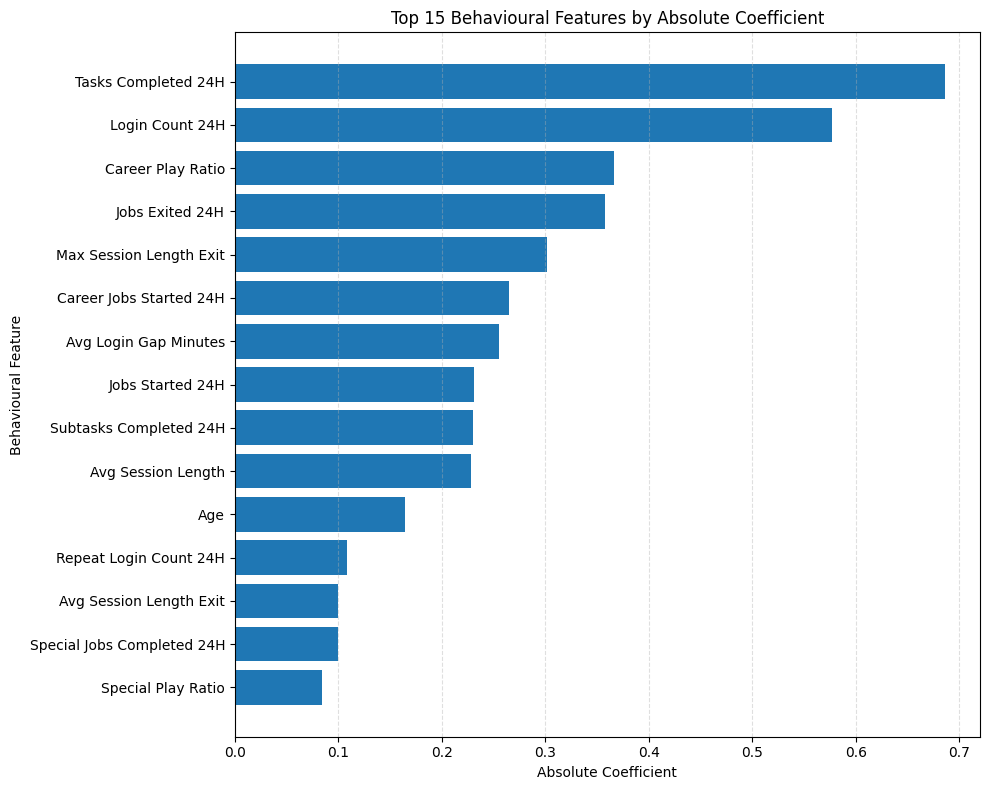

In [29]:
plt.figure(figsize=(10, 8))

top_features = (
    overall_behavioural
    .head(15)
    .sort_values(
        by="Absolute Coefficient"
    )
)

plt.barh(
    top_features["Display Feature"],
    top_features["Absolute Coefficient"]
)

plt.title(
    "Top 15 Behavioural Features by Absolute Coefficient"
)

plt.xlabel("Absolute Coefficient")

plt.ylabel("Behavioural Feature")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

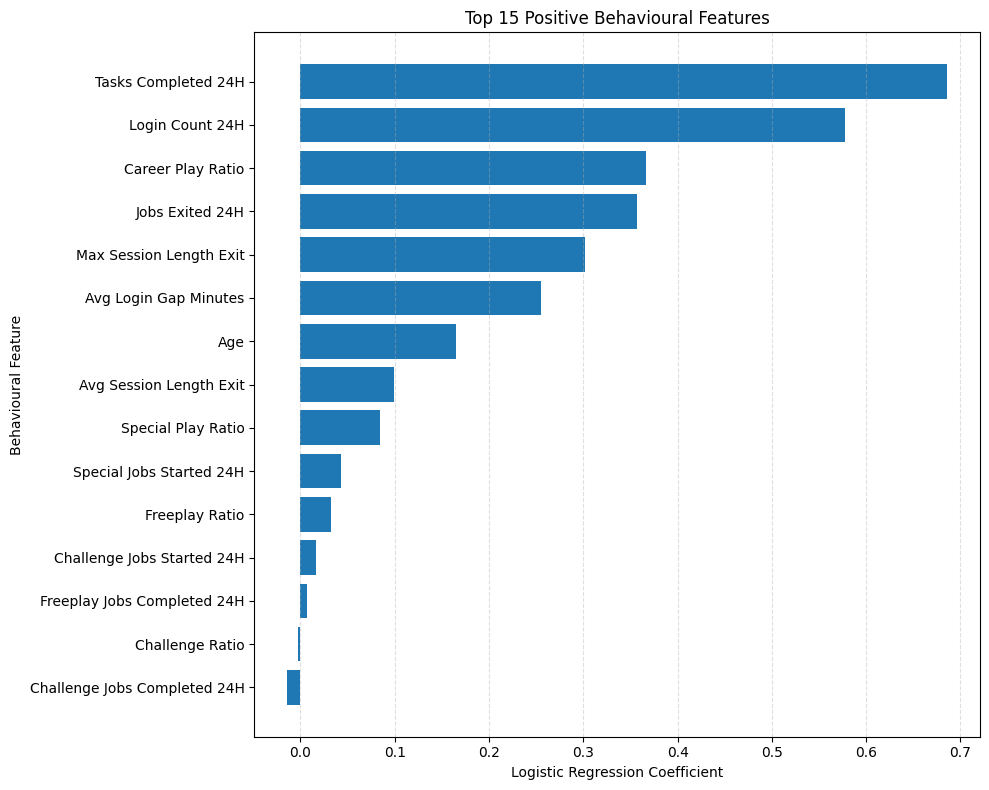

In [30]:
plt.figure(figsize=(10, 8))

top_positive = (
    positive_behavioural
    .head(15)
    .sort_values(
        by="Coefficient"
    )
)

plt.barh(
    top_positive["Display Feature"],
    top_positive["Coefficient"]
)

plt.title(
    "Top 15 Positive Behavioural Features"
)

plt.xlabel("Logistic Regression Coefficient")

plt.ylabel("Behavioural Feature")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

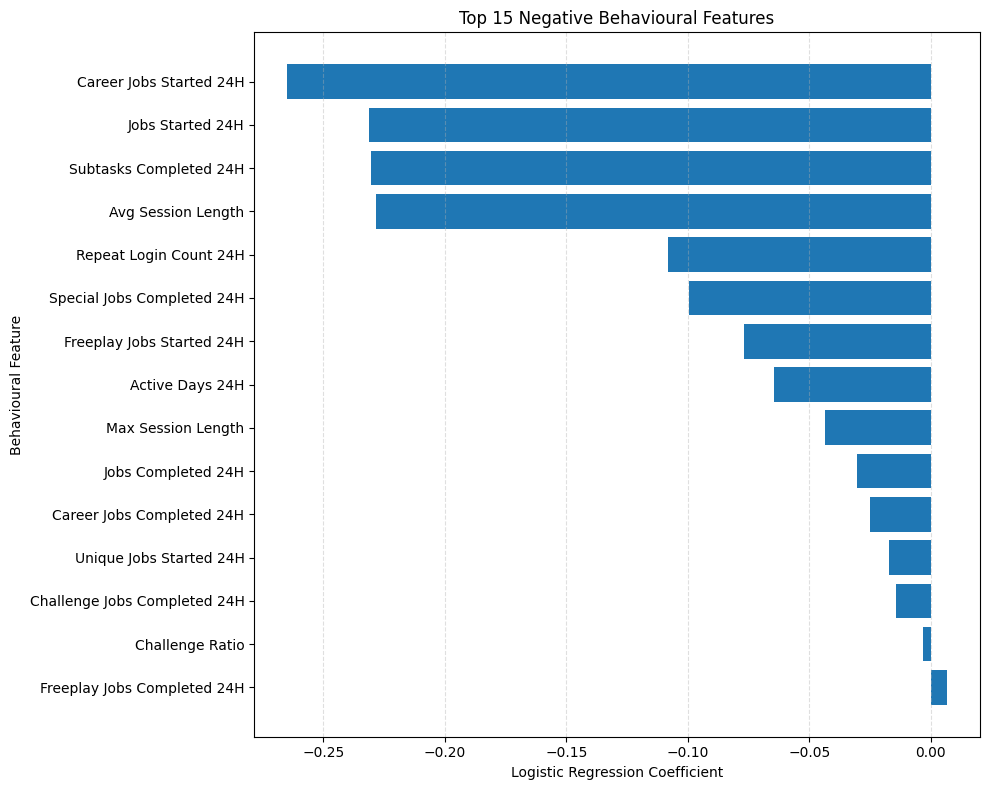

In [31]:
plt.figure(figsize=(10, 8))

top_negative = (
    negative_behavioural
    .head(15)
    .sort_values(
        by="Coefficient",
        ascending=False
    )
)

plt.barh(
    top_negative["Display Feature"],
    top_negative["Coefficient"]
)

plt.title(
    "Top 15 Negative Behavioural Features"
)

plt.xlabel("Logistic Regression Coefficient")

plt.ylabel("Behavioural Feature")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

In [33]:
# Load analytical dataset

df = pd.read_csv("../data/player_features_final.csv")

print(f"Dataset Shape: {df.shape}")

df.head()

Dataset Shape: (11080, 31)


,pid,age,gender,country,login_count_24h,repeat_login_count_24h,active_days_24h,avg_login_gap_minutes,jobs_started_24h,unique_jobs_started_24h,...,jobs_exited_24h,avg_session_length_exit,max_session_length_exit,avg_session_length,max_session_length,career_play_ratio,special_play_ratio,freeplay_ratio,challenge_ratio,retained
0,p126,29.0,Male,USA,0,0,0,0.0,0,0,...,0,0.0,0,0.0,0,0.0,0.0,0.0,0.0,0
1,p1317,35.0,Male,USA,0,0,0,0.0,0,0,...,0,0.0,0,0.0,0,0.0,0.0,0.0,0.0,0
2,p1661,18.0,Male,USA,0,0,0,0.0,0,0,...,0,0.0,0,0.0,0,0.0,0.0,0.0,0.0,0
3,p3338,24.0,Female,USA,0,0,0,0.0,0,0,...,0,0.0,0,0.0,0,0.0,0.0,0.0,0.0,0
4,p10095,32.0,Female,UK,1,0,1,0.0,1,1,...,2,106.5,155,58.0,58,1.0,0.0,0.0,0.0,0


In [34]:
X = df.drop(columns=["retained"])

y = df["retained"]

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [36]:
# Transform the test data using the fitted preprocessor

X_test_transformed = preprocessor.transform(X_test)

print(X_test_transformed.shape)

(2216, 122)


In [37]:
feature_names = preprocessor.get_feature_names_out()

len(feature_names)

122

In [38]:
X_test_transformed.shape[1]

122

In [39]:
assert len(feature_names) == X_test_transformed.shape[1]

In [54]:
player_data = X_test_transformed[player_index].toarray().flatten()

In [40]:
import shap

In [41]:
explainer = shap.LinearExplainer(
    logistic_model,
    X_test_transformed
)

In [42]:
shap_values = explainer.shap_values(X_test_transformed)

In [43]:
print(type(shap_values))
print(shap_values.shape)

<class 'numpy.ndarray'>
(2216, 122)


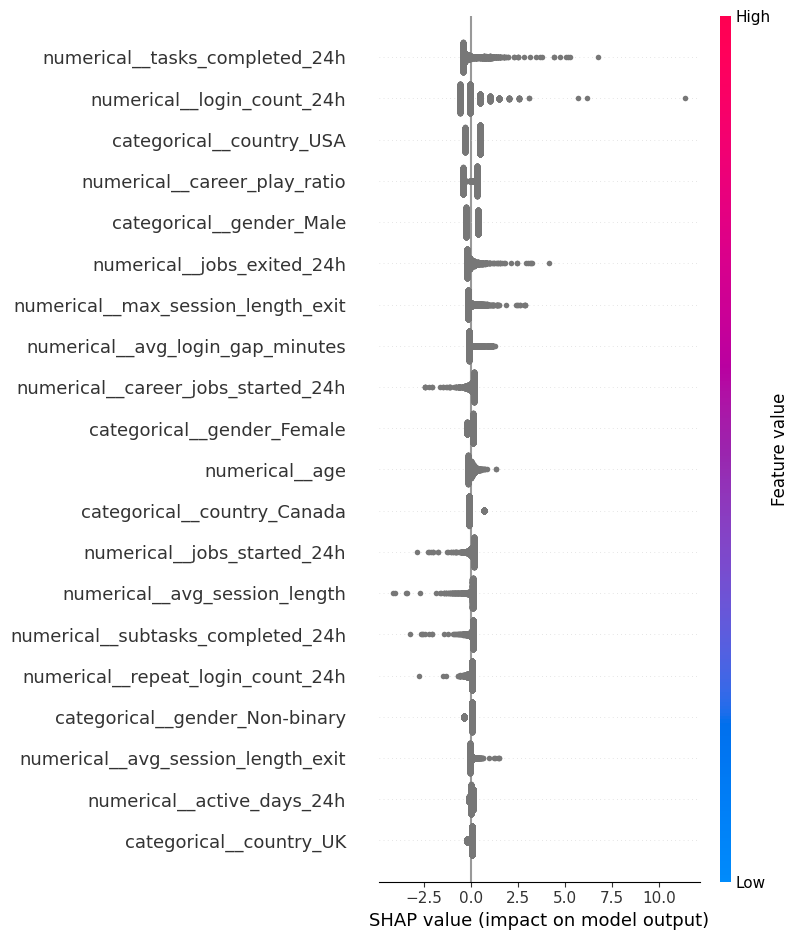

In [44]:
# SHAP Summary Plot

shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

In [45]:
X_test.iloc[25]

pid                              p5078
age                               30.0
gender                          Female
country                            USA
login_count_24h                      1
repeat_login_count_24h               0
active_days_24h                      1
avg_login_gap_minutes              0.0
jobs_started_24h                     1
unique_jobs_started_24h              1
career_jobs_started_24h              1
special_jobs_started_24h             0
freeplay_jobs_started_24h            0
challenge_jobs_started_24h           0
jobs_completed_24h                   1
career_jobs_completed_24h            1
special_jobs_completed_24h           0
freeplay_jobs_completed_24h          0
challenge_jobs_completed_24h         0
tasks_completed_24h                  8
subtasks_completed_24h              75
jobs_exited_24h                      2
avg_session_length_exit           55.5
max_session_length_exit             98
avg_session_length                13.0
max_session_length       

In [46]:
shap_values

array([[-0.00636363, -0.05733942,  0.05888095, ..., -0.35155676,
         0.        , -0.00115489],
       [-0.06251334,  0.46392801, -0.06912112, ...,  0.48548315,
         0.        , -0.00115489],
       [-0.04379677, -0.57860684,  0.05888095, ...,  0.48548315,
         0.        , -0.00115489],
       ...,
       [-0.00636363, -0.05733942,  0.05888095, ...,  0.48548315,
         0.        , -0.00115489],
       [-0.0250802 , -0.57860684,  0.05888095, ...,  0.48548315,
         0.        , -0.00115489],
       [-0.00636363, -0.05733942,  0.05888095, ...,  0.48548315,
         0.        , -0.00115489]])

In [47]:
player_index = 25
shap_values[player_index]

array([ 3.10695031e-02, -5.73394168e-02,  5.88809509e-02, -2.25874974e-02,
       -1.22094684e-01,  8.04165977e-02,  6.64508642e-03,  1.02154032e-01,
       -6.25040985e-03,  4.29071493e-03, -1.02128962e-18,  9.17880800e-03,
        7.94263826e-03,  2.00078548e-02, -3.84216323e-04, -9.77291344e-20,
        3.90175794e-01,  6.47922473e-02, -7.69667838e-02,  1.40746439e-02,
        5.34355160e-02,  4.62795273e-02,  1.40635861e-02,  3.11073850e-01,
       -5.73760856e-03, -2.16709335e-03,  3.09156456e-19, -2.40662252e-01,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
       -0.00000000e+00, -3.93740057e-03,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  3.68841042e-01,  0.00000000e+00,  0.00000000e+00,
       -0.00000000e+00,  0.00000000e+00, -0.00000000e+00, -0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  3.07144523e-02,
        0.00000000e+00,  0.00000000e+00, -0.00000000e+00, -0.00000000e+00,
        0.00000000e+00,  

In [48]:
predicted_probability = logistic_pipeline.predict_proba(
    X_test.iloc[[player_index]]
)[0][1]

print(predicted_probability)

0.8452301206206195


In [49]:
print("Actual:", y_test.iloc[player_index])

print("Predicted:", predicted_probability)

Actual: 1
Predicted: 0.8452301206206195


In [55]:
explanation = shap.Explanation(
    values=shap_values[player_index],
    base_values=explainer.expected_value,
    data=player_data,
    feature_names=feature_names
)

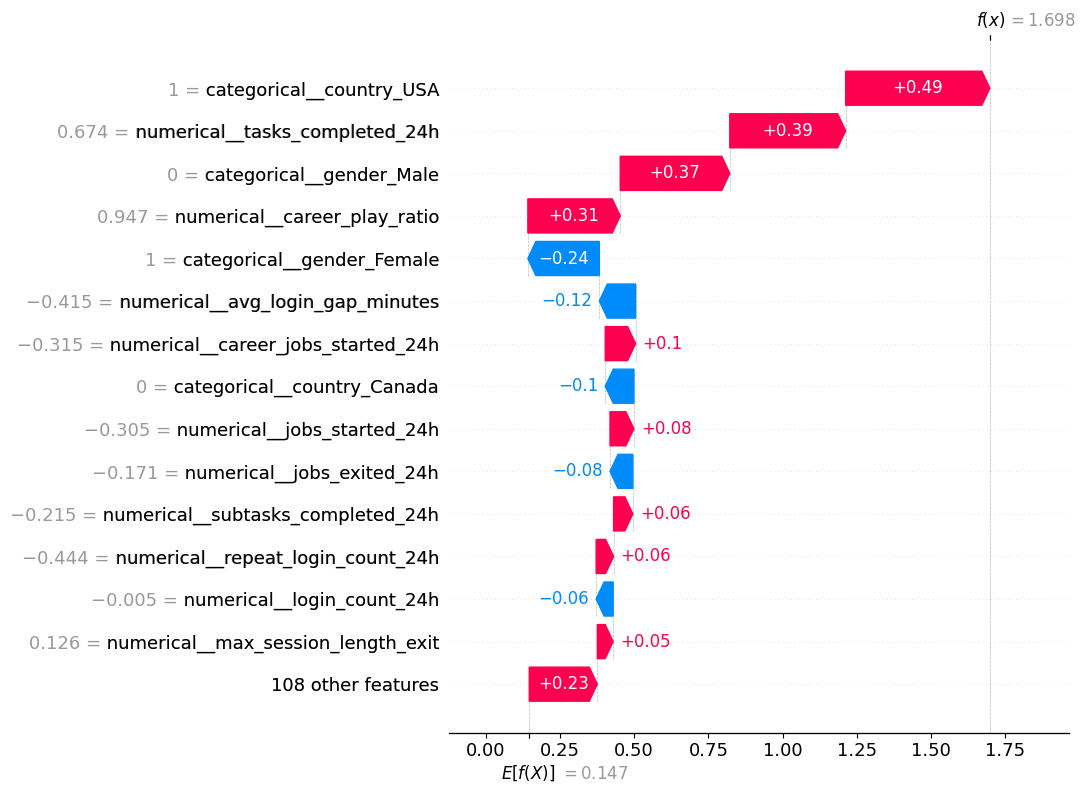

In [56]:
shap.plots.waterfall(
    explanation,
    max_display=15
)

In [58]:
import shap
print(shap.__version__)

0.49.1
